<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B0%D1%83%D0%B4%D0%B8%D0%BE%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Используя базу "Аудиожанры", примените подход к музыке как к тексту и напишите сверточный классификатор (на базе слоя Conv1D) для подготовленных данных. Для этого:

1. Измените подготовку данных так, чтобы набор признаков, извлекаемый из аудиофайла, был представлен в виде последовательностей векторов признаков. Последовательности должны быть фиксированного размера и выбираться скользящим окном c заданным шагом. Другими словами: берем аудио-файл длительность, например, 30 сек. Берем отрезок фиксированной длины (например, 5с) и получаем набор признаков для этого отрезка. Смещаемся на шаг (например, 1с) и берем следующий отрезок. Таким образом готовим обучающую вборку.
2. Длину последовательности, размер шага и достаточный набор признаков определите самостоятельно исходя из требований к точности классификатора;
3. Разработайте классификатор на одномерных сверточных слоях **Conv1D** с точностью классификации жанра на тестовых данных не ниже **60%**, а на обучающих файлах - **68%** и выше;
4. Используйте за основу материал с урока, но при желании разработайте свои инструменты.

Импортируем необходимые библиотеки:

In [15]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM
from tensorflow.keras.layers import MaxPooling1D, AveragePooling1D, SpatialDropout1D

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Загрузим датасет в Colab:

In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=True)

'genres.zip'

In [16]:
# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Проверка выгруженных папок
!ls genres

# Проверка содержимого одной папки
!ls genres/blues

blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock
blues.00000.au	blues.00020.au	blues.00040.au	blues.00060.au	blues.00080.au
blues.00001.au	blues.00021.au	blues.00041.au	blues.00061.au	blues.00081.au
blues.00002.au	blues.00022.au	blues.00042.au	blues.00062.au	blues.00082.au
blues.00003.au	blues.00023.au	blues.00043.au	blues.00063.au	blues.00083.au
blues.00004.au	blues.00024.au	blues.00044.au	blues.00064.au	blues.00084.au
blues.00005.au	blues.00025.au	blues.00045.au	blues.00065.au	blues.00085.au
blues.00006.au	blues.00026.au	blues.00046.au	blues.00066.au	blues.00086.au
blues.00007.au	blues.00027.au	blues.00047.au	blues.00067.au	blues.00087.au
blues.00008.au	blues.00028.au	blues.00048.au	blues.00068.au	blues.00088.au
blues.00009.au	blues.00029.au	blues.00049.au	blues.00069.au	blues.00089.au
blues.00010.au	blues.00030.au	blues.00050.au	blues.00070.au	blues.00090.au
blues.00011.au	blues.00031.au	blues.00051.au	blues.00071.au	blues.00091.au
blues.00012.au	blues.00032.a

In [17]:
# Ваше решение

# Установка констант

FILE_DIR = './genres'                     # Папка с файлами датасета
CLASS_LIST = os.listdir(FILE_DIR)         # Список классов, порядок меток не определен!
CLASS_LIST.sort()                         # Сортировка списка классов для фиксации порядка меток
CLASS_COUNT = len(CLASS_LIST)             # Количество классов
CLASS_FILES = 100                         # Общее количество файлов в каждом классе
FILE_INDEX_TRAIN_SPLIT = 90               # Количество файлов каждого класса на основной набор
VALIDATION_SPLIT = 0.1                    # Доля проверочной выборки в основном наборе
DURATION_SEC = 30                         # Анализируемая длительность аудиосигнала
N_FFT = 8192                              # Размер окна преобразования Фурье для расчета спектра
HOP_LENGTH = 512                          # Объем данных для расчета одного набора признаков
CONV_WIN_LEN_SEC=10                            # Длительность скользящего окна для свертки сек
CONV_WIN_STEP_SEC=3                           # Длина шага окна сек

In [18]:
# Функция параметризации аудио

def get_features(y,                     # волновое представление сигнала
                 sr,                    # частота дискретизации сигнала y
                 n_fft=N_FFT,           # размер скользящего окна БПФ
                 hop_length=HOP_LENGTH  # шаг скользящего окна БПФ
                 ):
    # Вычисление различных параметров (признаков) аудио

    # Хромаграмма
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Мел-кепстральные коэффициенты
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Среднеквадратическая амплитуда
    rmse = librosa.feature.rms(y=y, hop_length=hop_length)
    # Спектральный центроид
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Ширина полосы частот
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Спектральный спад частоты
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Пересечения нуля
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)

    # Сборка параметров в общий список:
    # На один файл один усредненный вектор признаков
    features = {'rmse': rmse.mean(axis=1, keepdims=True),
                'spct': spec_cent.mean(axis=1, keepdims=True),
                'spbw': spec_bw.mean(axis=1, keepdims=True),
                'roff': rolloff.mean(axis=1, keepdims=True),
                'zcr' : zcr.mean(axis=1, keepdims=True),
                'mfcc': mfcc.mean(axis=1, keepdims=True),
                'stft': chroma_stft.mean(axis=1, keepdims=True)}

    return features

In [6]:
# Функция объединения признаков в набор векторов

def stack_features(feat  # словарь признаков, отдельные векторы по ключу каждого признака
                   ):
    features = None
    for v in feat.values():
        features = np.vstack((features, v)) if features is not None else v

    return features.T

In [7]:
features_conv = []
for i in range(0, 5):
    feat = {'rmse': 11+i,
                    'spct': 22+i,
                    'spbw': 33+i,
                    'roff': 43+i,
                    'zcr' : 55+i,
                    'mfcc': 66+i,
                    'stft': 77+i}
    features = None
    for v in feat.values():
        features = np.vstack((features, v)) if features is not None else v
    display(features.T)
    display(features.T.shape)
    features_conv.append(features.T[0])
    print('-'*30)
display(np.array(features_conv))

array([[11, 22, 33, 43, 55, 66, 77]])

(1, 7)

------------------------------


array([[12, 23, 34, 44, 56, 67, 78]])

(1, 7)

...

------------------------------


array([[15, 26, 37, 47, 59, 70, 81]])

(1, 7)

------------------------------


array([[11, 22, 33, 43, 55, 66, 77],
       [12, 23, 34, 44, 56, 67, 78],
       [13, 24, 35, 45, 57, 68, 79],
       [14, 25, 36, 46, 58, 69, 80],
       [15, 26, 37, 47, 59, 70, 81]])

In [8]:
# Функция формирования набора признаков и метки класса для аудиофайла

def get_feature_list_from_file(class_index,  # индекс класса файла song_name
                               song_name,    # имя аудиофайла
                               duration_sec  # длительность аудио в секундах
                               ):
    # Загрузка в y первых duration_sec секунд аудиосигнала
    y, sr = librosa.load(song_name, mono=True, duration=duration_sec)
    conv_win_len = sr * CONV_WIN_LEN_SEC
    conv_win_step = sr * CONV_WIN_STEP_SEC
    duration = len(y)
    features_set_conv = []
    for start in range(0, duration, conv_win_step):
        # Извлечение параметров из аудиосигнала
        features = get_features(y[start:start+conv_win_len], sr)
        feature_set = stack_features(features)
        features_set_conv.append(feature_set[0])
    # Перевод номера класса в one hot encoding
    y_label = to_categorical(class_index, CLASS_COUNT)

    return np.array(features_set_conv), y_label

In [19]:
#поиск ошибки в логике: проверка набора данных к одному файлу
class_index=0
duration_sec=DURATION_SEC
file_index=0
class_name = CLASS_LIST[class_index]
song_name = f'{FILE_DIR}/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'
feature_set, y_label = get_feature_list_from_file(class_index,  # индекс класса файла song_name
                               song_name,    # имя аудиофайла
                               duration_sec  # длительность аудио в секундах
                               )
display(feature_set.shape)
display(y_label)
display(feature_set)

(10, 37)

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[ 1.24412641e-01,  1.82612820e+03,  2.05156131e+03,
         3.93127093e+03,  8.01109792e-02,  3.38802299e+01,
         1.25510933e+02, -2.06027946e+01,  4.37419930e+01,
        -7.63891554e+00,  2.15091457e+01, -1.69807777e+01,
         1.85334797e+01, -1.42350140e+01,  1.30811596e+01,
        -1.06847668e+01,  1.17427311e+01, -5.27029800e+00,
         8.52987003e+00, -7.59819651e+00,  1.86602998e+00,
        -4.20304298e+00,  1.84435678e+00, -3.87582135e+00,
         3.28731036e+00,  4.03273821e-01,  3.84022087e-01,
         4.19756979e-01,  2.21084222e-01,  2.73878902e-01,
         3.21009487e-01,  3.24659228e-01,  4.16809112e-01,
         2.59771347e-01,  3.20005834e-01,  3.66231859e-01,
         3.33903670e-01],
       [ 1.27411380e-01,  1.79550203e+03,  2.04874334e+03,
         3.87637001e+03,  7.61197615e-02,  3.64413681e+01,
         1.27621101e+02, -1.89121113e+01,  4.25560417e+01,
        -9.94869900e+00,  2.07113209e+01, -1.65070477e+01,
         1.82168369e+01, -1.44

In [20]:
# Функция формирования подвыборки признаков и меток класса для одного файла

def process_file(class_index,  # индекс класса аудиофайла
                 file_index,   # индекс (порядковый номер) аудиофайла в папке класса
                 duration_sec  # длительность аудио в секундах
                 ):
    x_list = []
    y_list = []
    class_name = CLASS_LIST[class_index]

    # Извлечение имени произведения
    song_name = f'{FILE_DIR}/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'

    # Выборка признаков и метки класса для произведения
    feature_set, y_label = get_feature_list_from_file(class_index,
                                                        song_name,
                                                        duration_sec)

    # Добавление данных в наборы
    for j in range(feature_set.shape[0]):
        x_list.append(feature_set[j])

    y_list.append(y_label)

    # Возврат имени файла и numpy-массивов призанков и меток класса
    return song_name, \
           np.array(x_list).astype('float32'), \
           np.array(y_list).astype('float32')

In [21]:
_, file_x_data, file_y_data = process_file(class_index,  # индекс класса аудиофайла
                 file_index,   # индекс (порядковый номер) аудиофайла в папке класса
                 duration_sec  # длительность аудио в секундах
                 )
display(file_x_data, file_y_data)
print(file_x_data.shape, file_y_data.shape)

array([[ 1.24412641e-01,  1.82612817e+03,  2.05156128e+03,
         3.93127100e+03,  8.01109821e-02,  3.38802299e+01,
         1.25510933e+02, -2.06027946e+01,  4.37419930e+01,
        -7.63891554e+00,  2.15091457e+01, -1.69807777e+01,
         1.85334797e+01, -1.42350140e+01,  1.30811596e+01,
        -1.06847668e+01,  1.17427311e+01, -5.27029800e+00,
         8.52987003e+00, -7.59819651e+00,  1.86602998e+00,
        -4.20304298e+00,  1.84435678e+00, -3.87582135e+00,
         3.28731036e+00,  4.03273821e-01,  3.84022087e-01,
         4.19756979e-01,  2.21084222e-01,  2.73878902e-01,
         3.21009487e-01,  3.24659228e-01,  4.16809112e-01,
         2.59771347e-01,  3.20005834e-01,  3.66231859e-01,
         3.33903670e-01],
       [ 1.27411380e-01,  1.79550208e+03,  2.04874341e+03,
         3.87637012e+03,  7.61197582e-02,  3.64413681e+01,
         1.27621101e+02, -1.89121113e+01,  4.25560417e+01,
        -9.94869900e+00,  2.07113209e+01, -1.65070477e+01,
         1.82168369e+01, -1.44

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

(10, 37) (1, 10)


In [22]:
# Функция формирования набора данных из файлов всех классов по диапазону номеров файлов


def extract_data(file_index_start,          # начальный индекс аудиофайла
                 file_index_end,            # конечный индекс аудиофайла (не достигая)
                 duration_sec=DURATION_SEC  # длительность аудио в секундах
                 ):

    # Списки для последовательностей входных данных и меток класса
    x_data = []
    y_data = None

    # Фиксация времени старта формирования выборки
    curr_time = time.time()

    # Для всех классов:
    for class_index in range(len(CLASS_LIST)):
        # Для всех файлов текущего класса из заданного диапазона номеров:
        for file_index in range(file_index_start, file_index_end):
            # Обработка одного файла и добавление данных к общим массивам
            _, file_x_data, file_y_data = process_file(class_index, file_index, duration_sec)

            x_data.append(file_x_data)
            y_data = file_y_data if y_data is None else np.vstack([y_data, file_y_data])

        # Вывод информации о готовности обработки датасета
        print(f'Жанр {CLASS_LIST[class_index]} готов -> {round(time.time() - curr_time)} c')
        curr_time = time.time()

    # Возврат массивов набора данных
    return np.array(x_data), y_data

In [23]:
# Проверка что генеррится в виде тренировочного (основного) набора данных
x_train_data, y_train_data = extract_data(0, 2)
display(x_train_data.shape, y_train_data.shape)
display(x_train_data, y_train_data)

Жанр blues готов -> 8 c
Жанр classical готов -> 9 c
Жанр country готов -> 9 c
Жанр disco готов -> 8 c
Жанр hiphop готов -> 9 c
Жанр jazz готов -> 9 c
Жанр metal готов -> 8 c
Жанр pop готов -> 9 c
Жанр reggae готов -> 9 c
Жанр rock готов -> 8 c


(20, 10, 37)

(20, 10)

array([[[1.24412641e-01, 1.82612817e+03, 2.05156128e+03, ...,
         3.20005834e-01, 3.66231859e-01, 3.33903670e-01],
        [1.27411380e-01, 1.79550208e+03, 2.04874341e+03, ...,
         3.13825369e-01, 4.36015308e-01, 3.81195873e-01],
        [1.36471927e-01, 1.78677271e+03, 2.04887158e+03, ...,
         3.07433754e-01, 4.44885105e-01, 3.45724910e-01],
        ...,
        [1.29331023e-01, 1.76184692e+03, 1.93122351e+03, ...,
         2.88871318e-01, 3.94328475e-01, 4.32572514e-01],
        [1.23677403e-01, 1.78936804e+03, 1.90729333e+03, ...,
         3.08920294e-01, 4.04235482e-01, 4.68085647e-01],
        [1.14406183e-01, 1.82071753e+03, 1.90680273e+03, ...,
         2.16051713e-01, 4.94220495e-01, 6.38147712e-01]],

       [[9.43250880e-02, 1.47699878e+03, 1.99315735e+03, ...,
         2.27997616e-01, 2.80908138e-01, 4.07822847e-01],
        [9.25022960e-02, 1.56901233e+03, 2.02586328e+03, ...,
         2.33013883e-01, 2.56274968e-01, 3.17670465e-01],
        [9.13552940e-02, 

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [24]:
# Формирование тренировочного (основного) набора данных
x_train_data, y_train_data = extract_data(0, FILE_INDEX_TRAIN_SPLIT)

Жанр blues готов -> 343 c
Жанр classical готов -> 369 c
Жанр country готов -> 375 c
Жанр disco готов -> 362 c
Жанр hiphop готов -> 379 c
Жанр jazz готов -> 335 c
Жанр metal готов -> 333 c
Жанр pop готов -> 319 c
Жанр reggae готов -> 346 c
Жанр rock готов -> 382 c


In [25]:
# Сохранение/восстановление датасета аудио
# Данные привязаны к порядку следования меток классов!
# Порядок классов фиксирован сортировкой списка меток классов
with open('audio_data_mean_conv.pickle', 'wb') as f:
    pickle.dump((x_train_data, y_train_data), f)

with open('audio_data_mean_conv.pickle', 'rb') as f:
    x_train_data, y_train_data = pickle.load(f)

In [26]:
print(x_train_data.shape)
print(y_train_data.shape)
display(x_train_data[:2])

(900, 10, 37)
(900, 10)


array([[[ 1.24412641e-01,  1.82612817e+03,  2.05156128e+03,
          3.93127100e+03,  8.01109821e-02,  3.38802299e+01,
          1.25510933e+02, -2.06027946e+01,  4.37419930e+01,
         -7.63891554e+00,  2.15091457e+01, -1.69807777e+01,
          1.85334797e+01, -1.42350140e+01,  1.30811596e+01,
         -1.06847668e+01,  1.17427311e+01, -5.27029800e+00,
          8.52987003e+00, -7.59819651e+00,  1.86602998e+00,
         -4.20304298e+00,  1.84435678e+00, -3.87582135e+00,
          3.28731036e+00,  4.03273821e-01,  3.84022087e-01,
          4.19756979e-01,  2.21084222e-01,  2.73878902e-01,
          3.21009487e-01,  3.24659228e-01,  4.16809112e-01,
          2.59771347e-01,  3.20005834e-01,  3.66231859e-01,
          3.33903670e-01],
        [ 1.27411380e-01,  1.79550208e+03,  2.04874341e+03,
          3.87637012e+03,  7.61197582e-02,  3.64413681e+01,
          1.27621101e+02, -1.89121113e+01,  4.25560417e+01,
         -9.94869900e+00,  2.07113209e+01, -1.65070477e+01,
          1.8

In [27]:
# Нормирование признаков в соответствии со стандартным нормальным распределением (используем reshape туда и обратно для обхода ограничения размерности)
x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data.reshape(x_train_data.shape[0]*x_train_data.shape[1], x_train_data.shape[2]))
display(x_train_data_scaled.shape)
x_train_data_scaled = x_train_data_scaled.reshape(x_train_data.shape[0],x_train_data.shape[1], x_train_data.shape[2])
display(x_train_data_scaled.shape)


(9000, 37)

(900, 10, 37)

In [28]:

# Разделение набора данных на обучающую и проверочную выборки
# Параметр stratify указывает метки классов, по которым происходит балансировка разделения
x_train, x_val, y_train, y_val = train_test_split(x_train_data_scaled,
                                                  y_train_data,
                                                  stratify=y_train_data,
                                                  test_size=VALIDATION_SPLIT)

In [29]:
print(x_train.shape)
print(y_train.shape)

(810, 10, 37)
(810, 10)


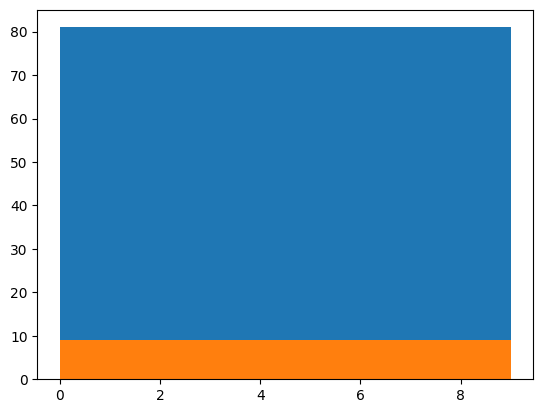

In [30]:
# Проверка сбалансированности выборок по классам
plt.hist(np.argmax(y_train, axis=1), CLASS_COUNT)
plt.hist(np.argmax(y_val, axis=1), CLASS_COUNT)
plt.show()

In [31]:
# Функция сборки и обучения классификатора на сверточных слоях

def create_train_classifier(in_shape,      # форма входных данных модели
                            epochs=200,    # количество эпох обучения
                            batch_size=20  # размер батча
                            ):
    model_conv = Sequential()
    model_conv.add(Conv1D(64, 5, input_shape=in_shape, activation='relu'))
    model_conv.add(Conv1D(64, 5, activation='relu'))
    model_conv.add(MaxPooling1D())
    model_conv.add(Flatten())
    model_conv.add(Dense(100, activation='relu'))
    model_conv.add(Dense(CLASS_COUNT, activation='softmax'))
    # Компиляция модели
    model_conv.compile(optimizer=Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    model_conv.summary()

    # Обучение модели
    history = model_conv.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графика точности распознавания на обучающей и проверочной выборках
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['accuracy'], label='Точность на обучающем наборе')
    plt.plot(history.history['val_accuracy'], label='Точность на проверочном наборе')
    plt.xticks(range(0, epochs, 10))
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()
    plt.show()

    return model_conv

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 64)          │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 64)          │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,958 (156.09 KB)

 Trainable params: 39,958 (156.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.1597 - loss: 2.3221 - val_accuracy: 0.3000 - val_loss: 2.1798
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2883 - loss: 2.1309 - val_accuracy: 0.3778 - val_loss: 2.0357
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3450 - loss: 1.9547 - val_accuracy: 0.3889 - val_loss: 1.8994
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3911 - loss: 1.7876 - val_accuracy: 0.3778 - val_loss: 1.7850
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4012 - loss: 1.6606 - val_accuracy: 0.4556 - val_loss: 1.6947
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4466 - loss: 1.5410 - val_accuracy: 0.4556 - val_loss: 1.6251
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4404 - loss: 1.5421 - val_accuracy: 0.4333 - val_loss: 1.5685
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5036 - loss: 1.4211 - val_accuracy: 0.4444 - 

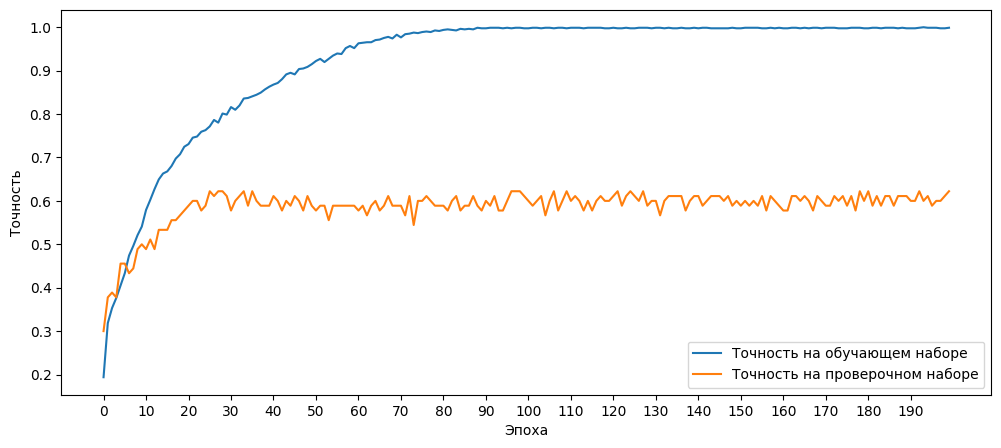

In [32]:
model = create_train_classifier(x_train.shape[1:])

In [33]:
# Сохранение/восстановление модели и выборок

model.save('model_audio_mean_conv.keras')
with open('audio_train_val_mean_conv.pickle', 'wb') as f:
    pickle.dump((x_train, y_train, x_val, y_val, x_scaler), f)

model = load_model('model_audio_mean_conv.keras')
with open('audio_train_val_mean_conv.pickle', 'rb') as f:
    x_train, y_train, x_val, y_val, x_scaler = pickle.load(f)

In [34]:
# Формирование тестовой выборки из файлов, не вошедших в основной набор

x_test, y_test = extract_data(FILE_INDEX_TRAIN_SPLIT, CLASS_FILES)

Жанр blues готов -> 48 c
Жанр classical готов -> 50 c
Жанр country готов -> 44 c
Жанр disco готов -> 43 c
Жанр hiphop готов -> 44 c
Жанр jazz готов -> 43 c
Жанр metal готов -> 43 c
Жанр pop готов -> 44 c
Жанр reggae готов -> 43 c
Жанр rock готов -> 45 c


In [35]:
# Нормирование признаков в соответствии со стандартным нормальным распределением (используем reshape туда и обратно для обхода ограничения размерности)
x_test_scaled = x_scaler.transform(x_test.reshape(x_test.shape[0]*x_test.shape[1], x_test.shape[2]))
display(x_test_scaled.shape)
x_test_scaled = x_test_scaled.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2])
display(x_test_scaled.shape)

(1000, 37)

(100, 10, 37)

In [36]:
# Функция оценки точности модели на заданной выборке

def eval_model(model,  # обученная модель нейронной сети
               x,      # входные данные
               y_true  # выходные данные (верные ответы)
               ):
    loss, acc = model.evaluate(x, y_true)
    print(f'Ошибка: {loss}, точность: {acc}')

    # Построение матрицы ошибок
    y_pred = model.predict(x)
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title('Матрица ошибок нормализованная')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 0.6158 - loss: 2.6478
Ошибка: 2.590787172317505, точность: 0.6222222447395325
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


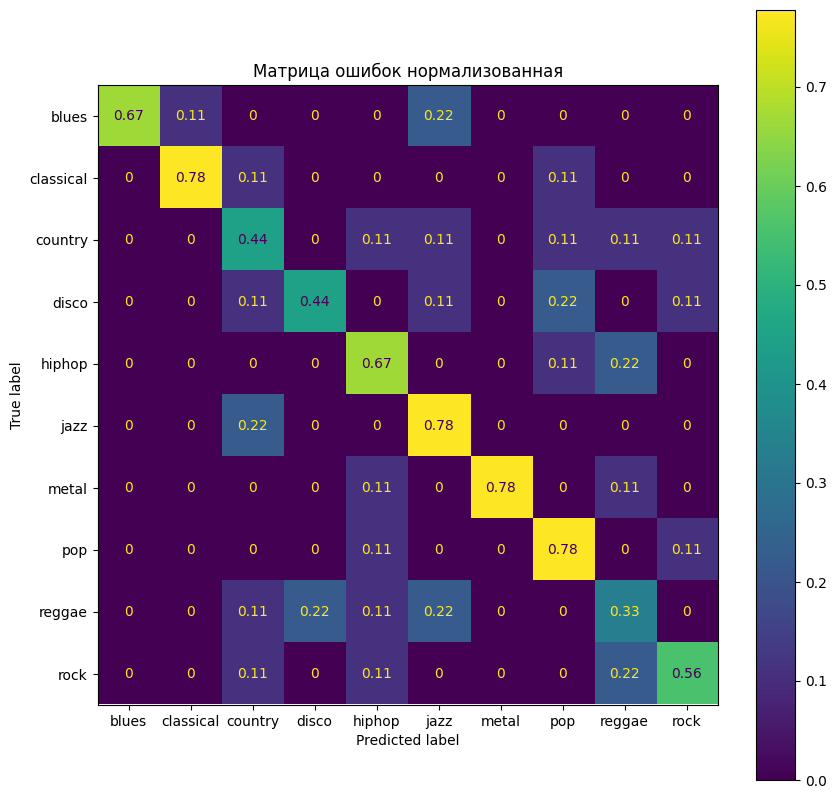

In [37]:
# Оценка точности сети на проверочной выборке
eval_model(model, x_val, y_val)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5334 - loss: 2.2521
Ошибка: 2.2403013706207275, точность: 0.5600000023841858
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


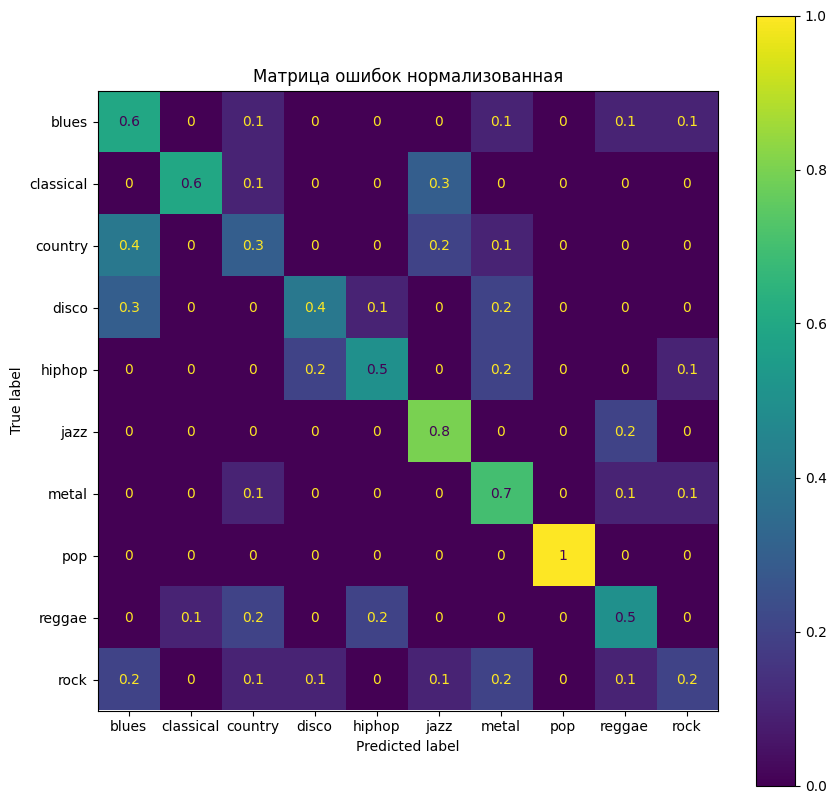

In [38]:
# Оценка точности сети на тестовой выборке
eval_model(model, x_test_scaled, y_test)